# Computer Vision Fundamentals - Edge Detection and Image Processing

This notebook demonstrates fundamental computer vision concepts including image loading, color channel separation, grayscale conversion, histogram analysis, binary thresholding, edge detection, and image downsampling. These techniques form the foundation of many computer vision applications.

## Overview of Tasks:
1. **Image Loading and Display** - Load and display an image
2. **Color Channel Separation** - Extract and visualize individual RGB channels
3. **Grayscale Conversion** - Convert color image to grayscale using averaging
4. **Histogram Analysis** - Analyze pixel intensity distributions
5. **Binary Thresholding** - Create binary images using intensity thresholds
6. **Edge Detection** - Detect edges using gradient-based methods
7. **Image Downsampling** - Create image pyramids through downsampling

Let's begin with the implementation!


In [4]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

## Task 1: Image Loading and Display

**Objective**: Load a color image and display it using OpenCV.

**What we're doing**: 
- Loading an image from the Images folder using `cv2.imread()`
- Displaying the image in a window using `cv2.imshow()`
- Saving the loaded image for reference
- Using `cv2.waitKey()` and `cv2.destroyAllWindows()` to properly manage the display window

**Key Concepts**:
- `cv2.IMREAD_COLOR`: Loads image in BGR color format (OpenCV's default)
- Image display requires proper window management in OpenCV

In [ ]:
# Load the original image from the Images folder
A = cv2.imread("./Images/shed1-small.jpg", cv2.IMREAD_COLOR)

# Display the loaded image
cv2.imshow('Image A', A)

# Save the image for reference in Images folder
cv2.imwrite('./Images/A.jpg', A)

# Wait for key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1) 

-1

## Task 2: Color Channel Separation

**Objective**: Separate the RGB color channels and visualize each channel individually.

**What we're doing**:
- Using `cv2.split()` to separate the BGR image into Blue, Green, and Red channels
- Creating individual channel images by merging each channel with zeros for the other two channels
- Displaying and saving each channel separately

**Key Concepts**:
- OpenCV uses BGR (Blue-Green-Red) format instead of RGB
- Each channel represents the intensity of that specific color component
- Channel separation helps analyze color distribution and is useful for various image processing tasks

In [ ]:
# Split the image into individual color channels (BGR format)
BC, GC, RC = cv2.split(A) 

# Create a zeros array with the same shape as the channels
zeros = np.zeros_like(BC)

# Create individual channel images by merging each channel with zeros
red_img = cv2.merge([zeros, zeros, RC])    # Red channel only
green_img = cv2.merge([zeros, GC, zeros])  # Green channel only
blue_img = cv2.merge([BC, zeros, zeros])   # Blue channel only

# Display each channel separately
cv2.imshow("Red Channel", red_img)
cv2.imshow("Green Channel", green_img)
cv2.imshow("Blue Channel", blue_img)

# Save each channel image in Images folder
cv2.imwrite('./Images/Red_Channel.jpg', red_img)
cv2.imwrite('./Images/Green_Channel.jpg', green_img)
cv2.imwrite('./Images/Blue_Channel.jpg', blue_img)

# Wait for key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)

-1

## Task 3: Grayscale Conversion

**Objective**: Convert the color image to grayscale using manual averaging of RGB channels.

**What we're doing**:
- Creating a grayscale image by averaging the Red, Green, and Blue channel values
- Manually implementing the conversion using nested loops
- Each pixel's grayscale value = (R + G + B) / 3

**Key Concepts**:
- Grayscale conversion reduces color information to intensity information only
- This is a fundamental preprocessing step for many computer vision algorithms
- The averaging method is simple but effective for basic grayscale conversion
- More sophisticated methods exist (like weighted averaging based on human perception) 

In [ ]:
# Create a grayscale image by averaging RGB channels
AG = np.zeros((512, 512), dtype=np.uint8)

# Manually convert each pixel to grayscale
for i in range(512):
    for j in range(512):
        # Average the three color channels for each pixel
        AG[i][j] = int((int(RC[i][j]) + int(GC[i][j]) + int(BC[i][j])) / 3)

# Display the grayscale image
cv2.imshow("AG", AG)

# Save the grayscale image in Images folder
cv2.imwrite('./Images/AG.jpg', AG)

# Wait for key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)  

-1

## Task 4: Histogram Analysis

**Objective**: Analyze the pixel intensity distribution of different image channels using histograms.

**What we're doing**:
- Creating a function to compute frequency histograms for pixel intensities (0-255)
- Computing histograms for Red, Green, Blue channels and the grayscale image
- Visualizing histograms using matplotlib to understand intensity distributions

**Key Concepts**:
- Histograms show the frequency distribution of pixel intensities
- They help understand image characteristics like contrast, brightness, and dynamic range
- Histogram analysis is crucial for image enhancement and thresholding operations
- Different channels may have different intensity distributions 

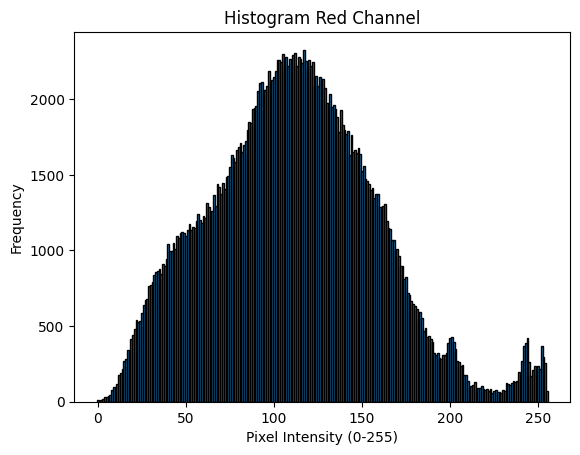

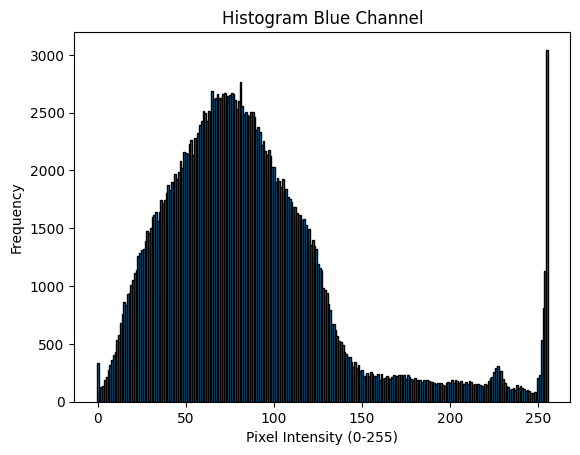

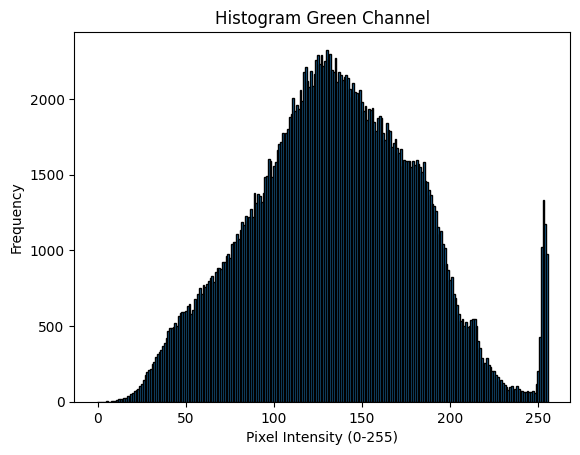

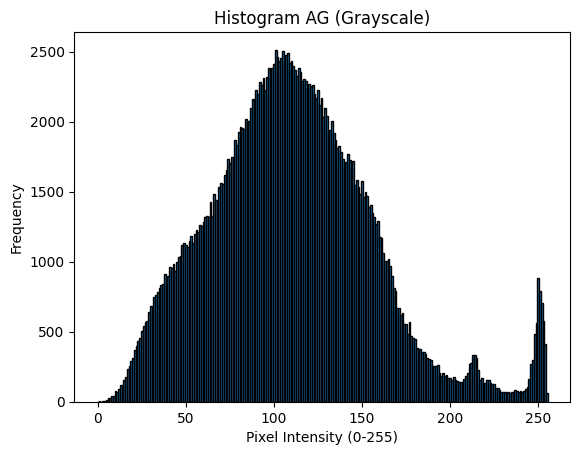

In [ ]:
# Function to compute pixel intensity frequency histogram
def frequency(image):
    arr = np.zeros(256)  # Array to store frequency of each intensity (0-255)
    for i in range(512):
        for j in range(512):
            arr[image[i][j]] += 1  # Increment count for this intensity value
    return arr

# Compute histograms for all channels
AG_arr = frequency(AG)  # Grayscale image histogram
RC_arr = frequency(RC)  # Red channel histogram
GC_arr = frequency(GC)  # Green channel histogram
BC_arr = frequency(BC)  # Blue channel histogram

# Create x-axis for histogram (intensity values 0-255)
x = np.arange(256)

# Plot Red Channel Histogram
plt.figure()
plt.title('Histogram Red Channel')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.bar(x, RC_arr, width=1.0, edgecolor='black')
plt.savefig("./Images/histogram_RC.jpg")
plt.show()

# Plot Blue Channel Histogram
plt.figure()
plt.title('Histogram Blue Channel')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.bar(x, BC_arr, width=1.0, edgecolor='black')
plt.savefig("./Images/histogram_BC.jpg")
plt.show()

# Plot Green Channel Histogram
plt.figure()
plt.title('Histogram Green Channel')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.bar(x, GC_arr, width=1.0, edgecolor='black')
plt.savefig("./Images/histogram_GC.jpg")
plt.show()

# Plot Grayscale Image Histogram
plt.figure()
plt.title('Histogram AG (Grayscale)')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.bar(x, AG_arr, width=1.0, edgecolor='black')
plt.savefig("./Images/histogram_AG.jpg")
plt.show()


## Task 5: Binary Thresholding

**Objective**: Create a binary (black and white) image using intensity thresholding.

**What we're doing**:
- Taking user input for a threshold value (TB)
- Converting the grayscale image to binary: pixels below threshold become black (0), pixels above become white (255)
- This creates a simple segmentation based on intensity

**Key Concepts**:
- Binary thresholding is a fundamental image segmentation technique
- It converts grayscale images to binary images using a threshold value
- Useful for separating objects from background based on intensity
- The choice of threshold significantly affects the result

In [ ]:
# Get threshold value from user
TB = int(input("Enter threshold value (0-255): "))

# Create binary image based on threshold
AB = np.zeros((512, 512), dtype=np.uint8)

# Apply thresholding: pixels below threshold = 0 (black), above = 255 (white)
for i in range(512):
    for j in range(512):
        if AG[i][j] < TB:
            AB[i][j] = 0      # Black
        else:
            AB[i][j] = 255    # White

# Display the binary image
cv2.imshow("Binary", AB)

# Save the binary image in Images folder
cv2.imwrite('./Images/AB.jpg', AB)

# Wait for key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)  
            
        

-1

## Task 6: Edge Detection

**Objective**: Detect edges in the grayscale image using gradient-based edge detection.

**What we're doing**:
- Computing horizontal (Gx) and vertical (Gy) gradients using finite differences
- Calculating gradient magnitude: Gm = √(Gx² + Gy²)
- Applying thresholding to the gradient magnitude to create edge image
- This implements a basic Sobel-like edge detection algorithm

**Key Concepts**:
- Edges are regions where intensity changes rapidly
- Gradients measure the rate of intensity change
- Horizontal gradient: difference between adjacent pixels in x-direction
- Vertical gradient: difference between adjacent pixels in y-direction
- Gradient magnitude combines both directions to detect edges in any orientation 

In [ ]:
# Get edge detection threshold from user
TE = int(input("Enter edge detection threshold: "))

# Initialize gradient arrays
Gx = np.zeros((512, 512), dtype=int)  # Horizontal gradient
Gy = np.zeros((512, 512), dtype=int)  # Vertical gradient
Gm = np.zeros((512, 512), dtype=float)  # Gradient magnitude

# Compute horizontal gradient (Gx) - difference between adjacent pixels in x-direction
for i in range(512):
    for j in range(511):  # Note: range(511) to avoid index out of bounds
        Gx[i][j] = int(AG[i][j+1]) - int(AG[i][j])

# Compute vertical gradient (Gy) - difference between adjacent pixels in y-direction
for i in range(511):  # Note: range(511) to avoid index out of bounds
    for j in range(512):
        Gy[i][j] = int(AG[i+1][j]) - int(AG[i][j])

# Compute gradient magnitude: Gm = √(Gx² + Gy²)
for i in range(512):
    for j in range(512):
        Gm[i][j] = math.sqrt(Gy[i][j]*Gy[i][j] + Gx[i][j]*Gx[i][j])

# Create edge image by thresholding gradient magnitude
AE = np.zeros((512, 512), dtype=np.uint8)

for i in range(512):
    for j in range(512):
        if Gm[i][j] < TE:
            AE[i][j] = 0      # No edge
        else:
            AE[i][j] = 255    # Edge detected

# Display the edge detection result
cv2.imshow("Edge Detection", AE)

# Save the edge image in Images folder
cv2.imwrite('./Images/Edge.jpg', AE)

# Wait for key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)  

-1

## Task 7: Image Downsampling (Image Pyramid)

**Objective**: Create multiple resolution levels of the image through recursive downsampling.

**What we're doing**:
- Implementing a recursive downsampling function that reduces image size by half at each level
- Using averaging of 2x2 pixel blocks to create smoother downsampled images
- Creating 3 levels: Level 1 (256x256), Level 2 (128x128), Level 3 (64x64)
- This creates an image pyramid useful for multi-scale analysis

**Key Concepts**:
- Image pyramids are hierarchical representations of images at different resolutions
- Downsampling reduces image size while preserving important features
- Averaging 2x2 blocks helps reduce aliasing artifacts
- Image pyramids are used in computer vision for multi-scale analysis, template matching, and feature detection

In [ ]:
# Recursive downsampling function
def downsample(img, c):
    # Base case: if c=1, return original image
    if c == 1:
        return img
    
    # Get image dimensions
    width = img.shape[1]
    height = img.shape[0]    
    
    # Create new image with half the dimensions
    new_img = np.zeros((height//2, width//2), dtype=np.uint8)
    
    # Downsample by averaging 2x2 blocks
    for i in range(height//2):
        for j in range(width//2):
            # Average 4 pixels in 2x2 block
            new_img[i][j] = (int(img[i*2][j*2]) + int(img[i*2][j*2+1]) + 
                            int(img[i*2+1][j*2]) + int(img[i*2+1][j*2+1])) // 4

    # Recursively downsample further
    return downsample(new_img, c//2)

# Create different resolution levels
AG2 = downsample(AG, 2)   # Level 1: 256x256
AG4 = downsample(AG, 4)   # Level 2: 128x128  
AG8 = downsample(AG, 8)   # Level 3: 64x64

# Display all pyramid levels
cv2.imshow("Level 1 (256x256)", AG2)
cv2.imshow("Level 2 (128x128)", AG4)
cv2.imshow("Level 3 (64x64)", AG8)

# Save pyramid levels in Images folder
cv2.imwrite('./Images/level1.jpg', AG2)
cv2.imwrite('./Images/level2.jpg', AG4)
cv2.imwrite('./Images/level3.jpg', AG8)

# Wait for key press and close windows
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1) 
        


-1

## Conclusion

This notebook demonstrated fundamental computer vision techniques that form the foundation of many advanced image processing and computer vision applications:

### Key Concepts Covered:

1. **Image Loading and Display**: Understanding how digital images are represented and displayed using OpenCV.

2. **Color Channel Separation**: Learning how color images are composed of separate color channels and how to extract them.

3. **Grayscale Conversion**: Converting color images to grayscale for simplified processing while preserving important visual information.

4. **Histogram Analysis**: Analyzing pixel intensity distributions to understand image characteristics like contrast and brightness.

5. **Binary Thresholding**: Creating binary images for segmentation tasks, separating objects from background based on intensity.

6. **Edge Detection**: Implementing gradient-based edge detection to identify boundaries and structural features in images.

7. **Image Downsampling**: Creating image pyramids for multi-scale analysis, useful in applications requiring different levels of detail.

### Applications:
These techniques are widely used in:
- **Medical Imaging**: Edge detection for organ boundary identification
- **Autonomous Vehicles**: Object detection and lane detection
- **Security Systems**: Face recognition and motion detection
- **Quality Control**: Defect detection in manufacturing
- **Digital Photography**: Image enhancement and filtering

### Next Steps:
- Explore more advanced edge detection algorithms (Canny, Sobel, Laplacian)
- Implement morphological operations for binary image processing
- Learn about feature detection and description (SIFT, SURF, ORB)
- Study image segmentation techniques beyond simple thresholding
- Experiment with different image enhancement methods

This foundation provides the building blocks for more sophisticated computer vision applications and machine learning-based image analysis.
